# Top tagging 

This notebook is dedicated to exploring the dataset and visualizing the features to gain insights into the data distribution and relationships between variables. We will use various plotting techniques to understand the characteristics of the dataset and identify any patterns or anomalies that may be present. 

The 3 main datasets wil be:
- **Top tagging**: This dataset contains information about top quark tagging, which is a technique used in particle physics to identify top quarks in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for top quark identification.
- **Quark-gluon jet tagging**: This dataset contains information about quark-gluon jet tagging, which is a technique used to distinguish between jets originating from quarks and gluons. The features in this dataset may include various jet substructure observables and kinematic variables that are relevant for quark-gluon discrimination.
- **Higgs tagging**: This dataset contains information about Higgs boson tagging, which is a technique used to identify Higgs bosons in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for Higgs boson identification.

We can find the dataset in the following path: `../data/val.h5`. We use the val test to not load 1 GB from train set. We will load the dataset and perform some exploratory data analysis to understand the distribution of the features and the relationships between them. We will start by loading the dataset and displaying some basic information about it, such as the number of samples, the number of features, and the distribution of the target variable. We will then create various plots to visualize the data, such as histograms, scatter plots, and correlation matrices. This will help us identify any patterns or anomalies in the data that may be relevant for our analysis.

**Description taken from the original source:** [zenodo](https://zenodo.org/records/2603256)

A set of MC simulated training/testing events for the evaluation of top quark tagging architectures.

In total 1.2M training events, 400k validation events and 400k test events. Use “train” for training, “val” for validation during the training and “test” for final testing and reporting results.

Description

- 14 TeV, hadronic tops for signal, qcd diets background, Delphes ATLAS detector card with Pythia8

- No MPI/pile-up included

- Clustering of  particle-flow entries (produced by Delphes E-flow) into anti-kT 0.8 jets in the pT range [550,650] GeV

- All top jets are matched to a parton-level top within ∆R = 0.8, and to all top decay partons within 0.8

- Jets are required to have |$\eta$| < 2

- The leading 200 jet constituent four-momenta are stored, with zero-padding for jets with fewer than 200

- Constituents are sorted by pT, with the highest pT one first

- The truth top four-momentum is stored as truth_px etc.

- A flag (1 for top, 0 for QCD) is kept for each jet. It is called is_signal_new

- The variable "ttv" (= test/train/validation) is kept for each jet. It indicates to which dataset the jet belongs. It is redundant as the different sets are already distributed as different files.

In [1]:
# Cargamos las librerías necesarias
import h5py
import hdf5plugin

In [2]:
try:
    with h5py.File('../data/val.h5', 'r') as f:
        print("File keys:", list(f.keys()))
        table = f['table']
        print("Table keys:", list(table.keys()))
        
        print("\n_i_table keys:", list(table['_i_table'].keys())) 
        print("table columns:", list(table['table'].dtype.names))

except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

File keys: ['table']
Table keys: ['_i_table', 'table']

_i_table keys: ['index']
table columns: ['index', 'values_block_0', 'values_block_1']


**_i_table key**

In [3]:
try:
    with h5py.File('../data/val.h5', 'r') as f:
        table = f['table']['_i_table']['index']
        print("_i_table keys:", list(table.keys()), "\n")
        
        for key in table.keys():
            print(f"{key}: shape {table[key].shape}, dtype {table[key].dtype}")

except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

_i_table keys: ['abounds', 'bounds', 'indices', 'indicesLR', 'mbounds', 'mranges', 'ranges', 'sorted', 'sortedLR', 'zbounds'] 

abounds: shape (384,), dtype int64
bounds: shape (3, 127), dtype int64
indices: shape (3, 131072), dtype uint32
indicesLR: shape (131072,), dtype uint32
mbounds: shape (384,), dtype int64
mranges: shape (3,), dtype int64
ranges: shape (3, 2), dtype int64
sorted: shape (3, 131072), dtype int64
sortedLR: shape (131201,), dtype int64
zbounds: shape (384,), dtype int64


This `_i_table` entry is a list of Optimized Index, so we will focus on `table` entry.

**table key**

In [4]:
try:
    with h5py.File('../data/val.h5', 'r') as f:   
        table = f['table']['table']
        print("Table keys:", list(table.dtype.names), "\n")
        
        for key in table.dtype.names:
            print(f"{key}: shape {table[key].shape}, dtype {table[key].dtype}")
except Exception as e:
    print(f"Error loading data using hdf5plugin: {e}")

Table keys: ['index', 'values_block_0', 'values_block_1'] 

index: shape (403000,), dtype int64
values_block_0: shape (403000, 804), dtype float32
values_block_1: shape (403000, 2), dtype int64


Let's see what is inside

## Data exploration

In [3]:
import polars as pl
#import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np
import h5py
import hdf5plugin

The description mentions store the four-momenta of the leading 200 jet constituyents and the four-momenta of the truth top. In order to know which was stored firts lets see the statistic description of the 0 and 800 file.

In [5]:
# Load the data
try:
    with h5py.File('../data/val.h5', 'r') as f:
        table = f['table']['table']
        # We take just 100 000 file to this first part
        x_qt_data = table['values_block_0'][:]
        y_qt_data = table['values_block_1'][:]

        df_comprobation = pl.DataFrame({
            "px_particle_1": x_qt_data[:, 0],
            "px_truth_top": x_qt_data[:, 800]
        })

        print(df_comprobation.describe())

except Exception as e:
    print(f"Error: {e}")

Error: name 'pl' is not defined


We can see zeros in the 800-th column and also bigger energy. This means that the first column is for the first jet constituent, and the 800-th is for the truth top.

Now, let's analice the subparticles.

In [7]:
SEED = 42

## Data visualization

For the previous analysis, there are only 50 424 particles to analice.

In [8]:
# import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
# import numpy as np
# import h5py
# import hdf5plugin

In [29]:
x_visual = x_qt_data[:50000, :800]
y_visual = y_qt_data[:50000, 1]

# Central axis momenta
jet_px = x_visual[:, 0::4].sum(axis=1)
jet_py = x_visual[:, 1::4].sum(axis=1)
jet_pz = x_visual[:, 2::4].sum(axis=1)

# Compute derived quantities
jet_pt = np.sqrt(jet_px**2 + jet_py**2)
jet_theta = np.arctan2(jet_pt, jet_pz)
jet_eta = -np.log(np.tan(jet_theta / 2.0), where=(jet_theta > 0), out=np.zeros_like(jet_theta))
jet_phi = np.arctan2(jet_py, jet_px)

# Angles
particulas_px = x_visual[:, 0:20:4].flatten()
particulas_py = x_visual[:, 1:20:4].flatten()
particulas_pz = x_visual[:, 2:20:4].flatten()

jet_eta_rep = np.repeat(jet_eta, 5)
jet_phi_rep = np.repeat(jet_phi, 5)
y_rep = np.repeat(y_visual, 5)

# compute particle angles
p_pt = np.sqrt(particulas_px**2 + particulas_py**2)
p_theta = np.arctan2(p_pt, particulas_pz)
p_eta = -np.log(np.tan(p_theta / 2.0), where=(p_theta > 0), out=np.zeros_like(p_theta))
p_phi = np.arctan2(particulas_py, particulas_px)
p_energy = x_visual[:, 3:20:4].flatten()  # Energía de cada partícula


In [30]:
# dataframe
df_viz = pl.DataFrame({
    "delta_eta": p_eta - jet_eta_rep,
    "delta_phi": p_phi - jet_phi_rep,
    "energy": p_energy,
    "class": y_rep
}).filter((pl.col("delta_eta") != 0) & (pl.col("delta_phi") != 0))

top_data = df_viz.filter(pl.col("class") == 1)
background_data = df_viz.filter(pl.col("class") == 0)

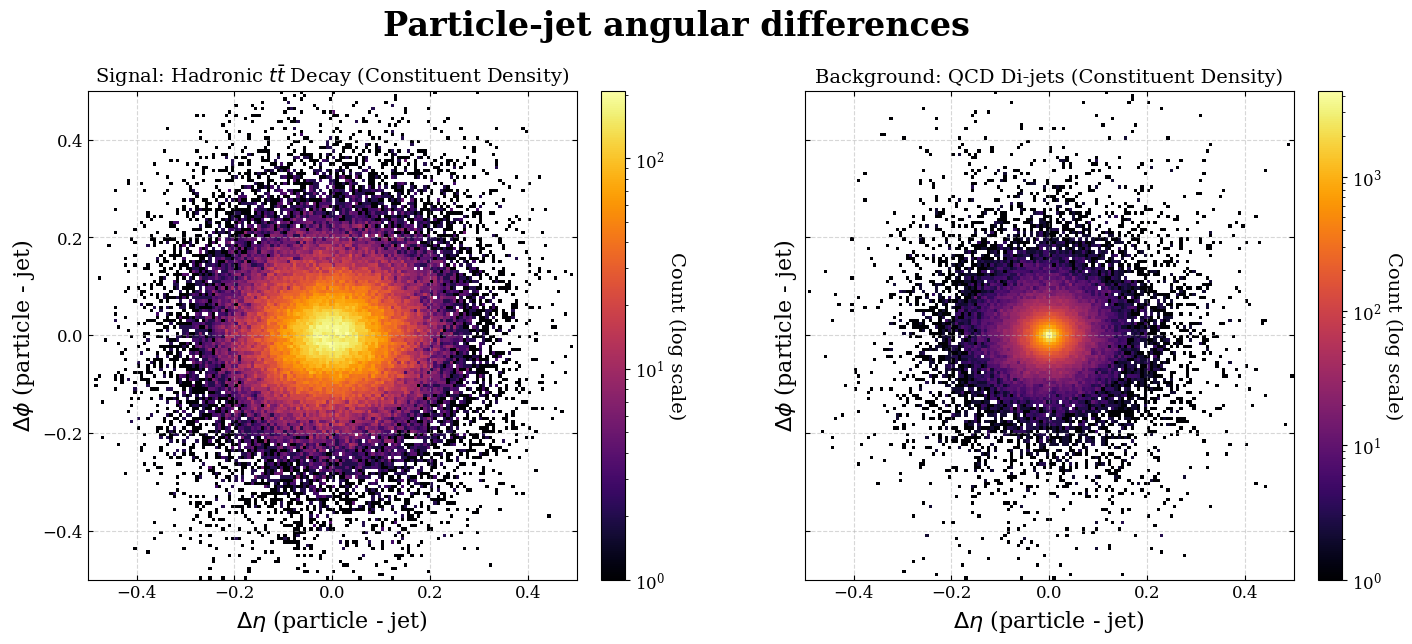

In [57]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "font.family": "serif"
})

# sig vs bkg
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
img_range = [[-0.5, 0.5], [-0.5, 0.5]]
bin_resolution = 150

# Top quark signal
im0 = axes[0].hist2d(top_data["delta_eta"].to_numpy(), 
                    top_data["delta_phi"].to_numpy(), 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[0].set_title(r"Signal: Hadronic $t\bar{t}$ Decay (Constituent Density)", fontsize=14)
axes[0].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[0].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

# Background
im1 = axes[1].hist2d(background_data["delta_eta"].to_numpy(), 
                    background_data["delta_phi"].to_numpy(), 
                    bins=bin_resolution, 
                    range=img_range,
                    cmap="inferno",
                    norm=LogNorm())
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Count (log scale)", rotation=270, labelpad=15)
axes[1].set_title("Background: QCD Di-jets (Constituent Density)", fontsize=14)
axes[1].set_xlabel("$\\Delta \\eta$ (particle - jet)", fontsize=16)
axes[1].set_ylabel("$\\Delta \\phi$ (particle - jet)", fontsize=16)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(img_range[0])
    ax.set_ylim(img_range[1])
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Particle-jet angular differences", fontsize=24, fontweight='bold')
plt.tight_layout()#rect=[0, 0, 1, 0.95])
plt.show()

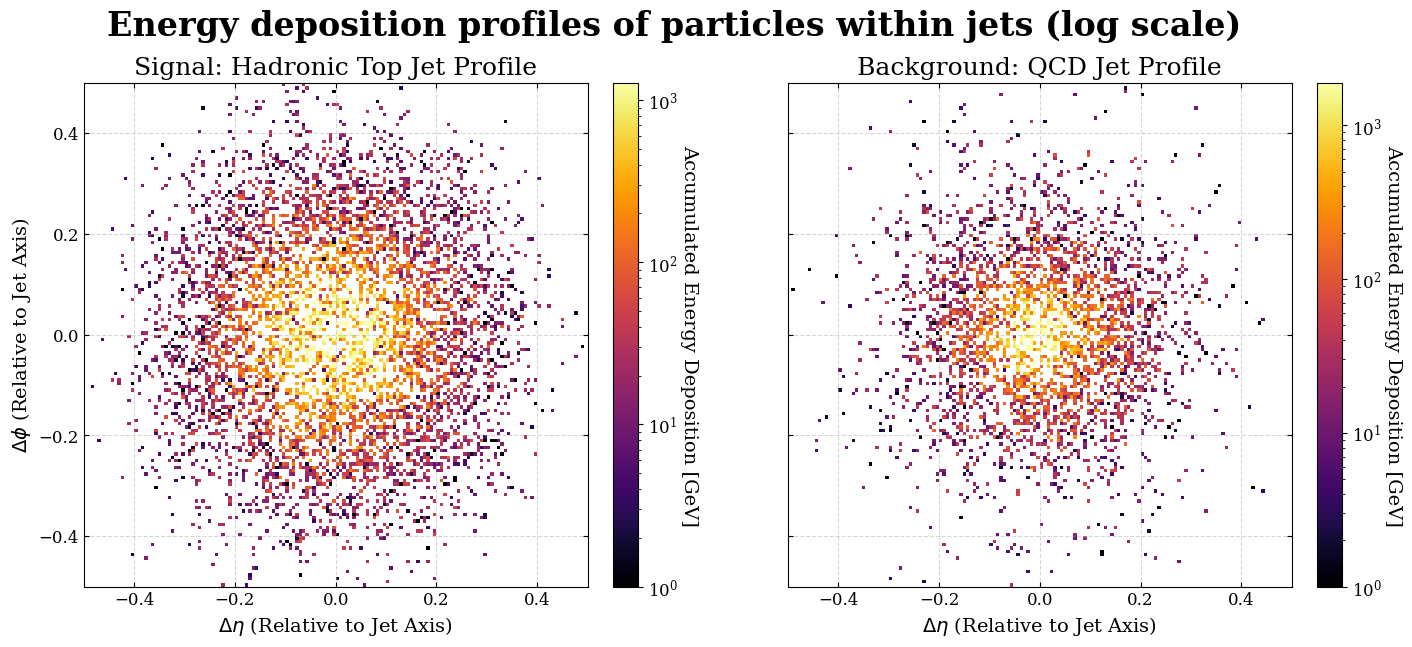

In [ ]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'font.family': 'serif',
    'text.usetex': False
})

# Create the canvas: 1 row, 2 columns with shared axes
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)

# Physical range of the Jet where the decay occurs (Anti-kT R=0.8, centered at 0.5)
img_range = [[-0.5, 0.5], [-0.5, 0.5]]
resolucion_pixeles = 150 

# ================= 1. SIGNAL ENERGY PROFILE (TOP QUARK) =================
im0 = axes[0].hist2d(
    top_data["delta_eta"].to_numpy(), 
    top_data["delta_phi"].to_numpy(), 
    weights=top_data["energy"].to_numpy(),  # weighted by Energy
    bins=resolucion_pixeles, 
    range=img_range, 
    cmap="inferno",
    norm=LogNorm(vmin=1.0, vmax=top_data["energy"].to_numpy().max())                          # Escala logarítmica para el rango dinámico de energía
)

# Side colorbar dedicated for the Top quark signal
cbar0 = fig.colorbar(im0[3], ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label('Accumulated Energy Deposition [GeV]', rotation=270, labelpad=15)

axes[0].set_title(r"Signal: Hadronic Top Jet Profile", fontsize=18)
axes[0].set_xlabel(r"$\Delta\eta$ (Relative to Jet Axis)")
axes[0].set_ylabel(r"$\Delta\phi$ (Relative to Jet Axis)")


# ================= 2. BACKGROUND ENERGY PROFILE (QCD) =================
im1 = axes[1].hist2d(
    background_data["delta_eta"].to_numpy(), 
    background_data["delta_phi"].to_numpy(), 
    weights=background_data["energy"].to_numpy(),  # weighted by Energy
    bins=resolucion_pixeles, 
    range=img_range, 
    cmap="inferno",
    norm=LogNorm(vmin=1.0, vmax=background_data["energy"].to_numpy().max())
)

# Side colorbar dedicated for the QCD background
cbar1 = fig.colorbar(im1[3], ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label('Accumulated Energy Deposition [GeV]', rotation=270, labelpad=15)

axes[1].set_title("Background: QCD Jet Profile", fontsize=18)
axes[1].set_xlabel(r"$\Delta\eta$ (Relative to Jet Axis)")
axes[1].set_ylabel(r"$\Delta\phi$ (Relative to Jet Axis)")

# ================= EXPERIMENTAL GEOMETRY ADJUSTMENTS =================
for ax in axes:
    ax.set_aspect('equal')              # Strict 1:1 ratio to avoid jet distortion
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.tick_params(direction='in', top=True, right=True)        # Ticks inward
    ax.grid(True, linestyle='--', alpha=0.5)                      # Grids to appreciate energy texture

plt.suptitle("Energy deposition profiles of particles within jets (log scale)", 
            fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# --- Style ---
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "font.family": "serif"
})

# Definition of colors
TOP_COLOR = '#1f77b4'  # Blue for the signal (Hadronic Top)
QCD_COLOR = '#9467bd'  # Purple for the background (QCD Di-jets)

# ==============================================================================
# INITIAL KINEMATIC PREPARATION WITH POLARS
# ==============================================================================
X_matriz = x_qt_data[:40000, :800]  
y_target = y_qt_data[:40000, 1]

# Calculate the central axes of the Jet per event (spatial reduction of the 200 components)
jet_px = X_matriz[:, 0::4].sum(axis=1)
jet_py = X_matriz[:, 1::4].sum(axis=1)
jet_pz = X_matriz[:, 2::4].sum(axis=1)
jet_pt_total = np.sqrt(jet_px**2 + jet_py**2)
jet_phi_total = np.arctan2(jet_py, jet_px)
jet_theta_total = np.arctan2(jet_pt_total, jet_pz)
jet_eta_total = -np.log(np.tan(jet_theta_total / 2.0), where=(jet_theta_total > 0), out=np.zeros_like(jet_theta_total))

# Flatten the main constituents in a structured way (e.g., the first 15 per Jet)
N_constituents = 15
p_px = X_matriz[:, 0 : N_constituents*4 : 4].flatten()
p_py = X_matriz[:, 1 : N_constituents*4 : 4].flatten()
p_pz = X_matriz[:, 2 : N_constituents*4 : 4].flatten()
p_energy = X_matriz[:, 3 : N_constituents*4 : 4].flatten()

p_pt = np.sqrt(p_px**2 + p_py**2)
p_theta = np.arctan2(p_pt, p_pz)
p_eta = -np.log(np.tan(p_theta / 2.0), where=(p_pt > 0), out=np.zeros_like(p_pt))
p_phi = np.arctan2(p_py, p_px)

# Repeat the jet kinematics for each event to calculate the relative plane
jet_eta_rep = np.repeat(jet_eta_total, N_constituents)
jet_phi_rep = np.repeat(jet_phi_total, N_constituents)
target_rep = np.repeat(y_target, N_constituents)

# Construct the centralized DataFrame in Polars for analytical profiles
df_reals = pl.DataFrame({
    "d_eta": p_eta - jet_eta_rep,
    "d_phi": p_phi - jet_phi_rep,
    "pt": p_pt,
    "energy": p_energy,
    "target": target_rep
}).filter((pl.col("energy") > 0)) # Clean removal of active zero-padding

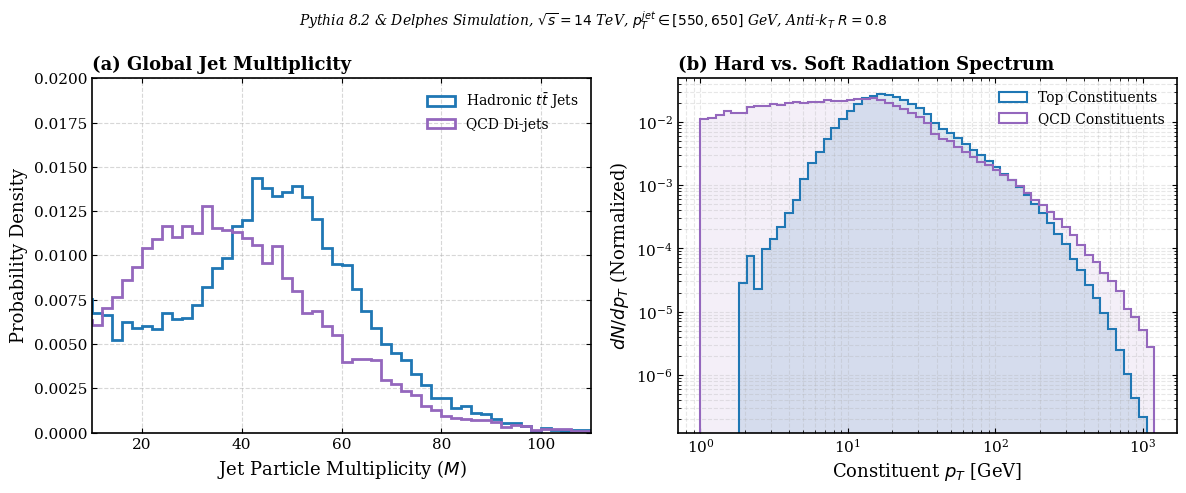

In [ ]:
# ==============================================================================
# PANEL 1: GLOBAL EVENT PROPERTIES (2 Subplots)
# ==============================================================================
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))

# --- Subplot A: Real Multiplicity Histogram ---
# Count how many constituents with E > 0 each original individual jet has
matriz_energias_completa = X_matriz[:, 3::4]
multiplicidad_por_evento = np.count_nonzero(matriz_energias_completa > 0, axis=1)

mult_top = multiplicidad_por_evento[y_target == 1]
mult_qcd = multiplicidad_por_evento[y_target == 0]

bins_mult = np.arange(0, 120, 2)
ax1[0].hist(mult_top, bins=bins_mult, histtype="step", lw=2, color=TOP_COLOR, label=r"Hadronic $t\bar{t}$ Jets", density=True)
ax1[0].hist(mult_qcd, bins=bins_mult, histtype="step", lw=2, color=QCD_COLOR, label="QCD Di-jets", density=True)

ax1[0].set_xlabel(r"Jet Particle Multiplicity ($M$)")
ax1[0].set_ylabel("Probability Density")
ax1[0].set_xlim(10, 110)
ax1[0].set_ylim(0, 0.02)
ax1[0].grid(True, linestyle="--", alpha=0.5)
ax1[0].legend(frameon=False)
ax1[0].set_title("(a) Global Jet Multiplicity", loc="left", fontweight="bold")

# --- Subplot B: Transverse Momentum Spectrum (Log-Scale) ---
pt_top = df_reals.filter(pl.col("target") == 1)["pt"].to_numpy()
pt_qcd = df_reals.filter(pl.col("target") == 0)["pt"].to_numpy()

bins_pt = np.logspace(np.log10(1.0), np.log10(1200), 60)
ax1[1].hist(pt_top, bins=bins_pt, histtype="stepfilled", alpha=0.15, color=TOP_COLOR, density=True)
ax1[1].hist(pt_top, bins=bins_pt, histtype="step", lw=1.5, color=TOP_COLOR, label="Top Constituents", density=True)
ax1[1].hist(pt_qcd, bins=bins_pt, histtype="stepfilled", alpha=0.1, color=QCD_COLOR, density=True)
ax1[1].hist(pt_qcd, bins=bins_pt, histtype="step", lw=1.5, color=QCD_COLOR, label="QCD Constituents", density=True)

ax1[1].set_xscale("log")
ax1[1].set_yscale("log")
ax1[1].set_xlabel(r"Constituent $p_T$ [GeV]")
ax1[1].set_ylabel(r"$dN / dp_T$ (Normalized)")
ax1[1].grid(True, which="both", linestyle="--", alpha=0.3)
ax1[1].legend(frameon=False)
ax1[1].set_title("(b) Hard vs. Soft Radiation Spectrum", loc="left", fontweight="bold")

fig1.suptitle(r"Pythia 8.2 & Delphes Simulation, $\sqrt{s} = 14$ TeV, $p_T^{jet} \in [550, 650]$ GeV, Anti-$k_T$ $R=0.8$", fontsize=10, y=0.98, style="italic")
plt.tight_layout()
# fig1.savefig("panel1_top_global_properties.pdf", dpi=300)
plt.show()

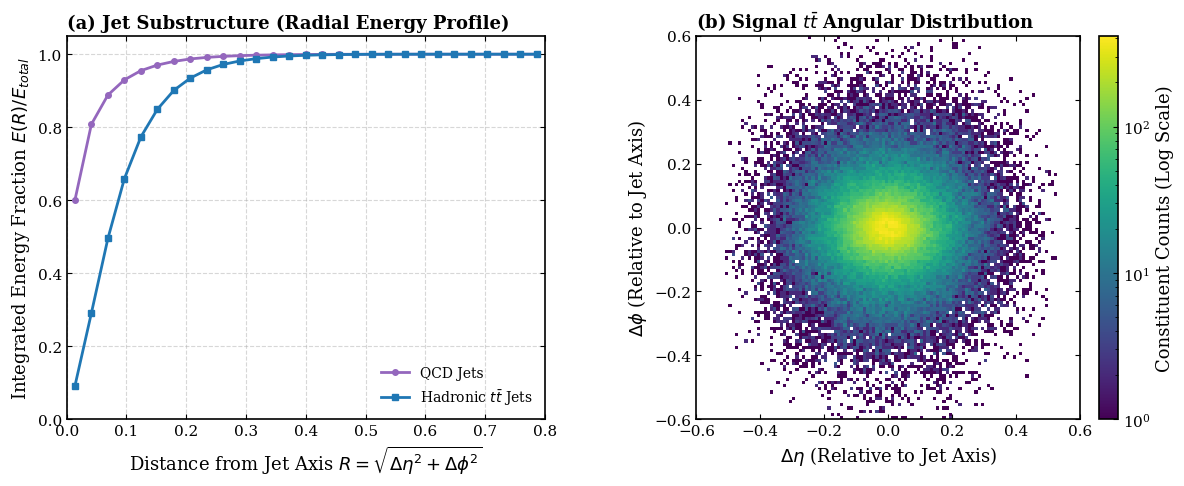

In [ ]:
# ==============================================================================
# PANEL 2: INTERNAL GEOMETRY AND ANGULAR DISTRIBUTION (2 Subplots)
# ==============================================================================
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))

# --- Subplot A: Radial Energy Profile Limited to R=0.8 ---
df_radial = df_reals.with_columns(
    (pl.col("d_eta")**2 + pl.col("d_phi")**2).sqrt().alias("r")
)

r_bins = np.linspace(0, 0.8, 30) # Limited to the total cone of the algorithm R=0.8
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
profile_top, profile_qcd = [], []

for i in range(len(r_bins)-1):
    r_min, r_max = r_bins[i], r_bins[i+1]
    pt_sum = (df_radial.filter((pl.col("r") >= r_min) & (pl.col("r") < r_max))
              .group_by("target").agg(pl.col("energy").sum()).sort("target"))
    
    sum_qcd = pt_sum.filter(pl.col("target") == 0)["energy"].to_numpy()
    sum_top = pt_sum.filter(pl.col("target") == 1)["energy"].to_numpy()
    profile_qcd.append(sum_qcd[0] if len(sum_qcd) > 0 else 0)
    profile_top.append(sum_top[0] if len(sum_top) > 0 else 0)

cum_profile_qcd = np.cumsum(profile_qcd) / np.sum(profile_qcd)
cum_profile_top = np.cumsum(profile_top) / np.sum(profile_top)

ax2[0].plot(r_centers, cum_profile_qcd, marker='o', ls='-', color=QCD_COLOR, label="QCD Jets", lw=2, markersize=4)
ax2[0].plot(r_centers, cum_profile_top, marker='s', ls='-', color=TOP_COLOR, label=r"Hadronic $t\bar{t}$ Jets", lw=2, markersize=4)
ax2[0].set_xlabel(r"Distance from Jet Axis $R = \sqrt{\Delta \eta^2 + \Delta \phi^2}$")
ax2[0].set_ylabel(r"Integrated Energy Fraction $E(R)/E_{total}$")
ax2[0].set_xlim(0, 0.8)
ax2[0].set_ylim(0, 1.05)
ax2[0].grid(True, linestyle="--", alpha=0.5)
ax2[0].legend(frameon=False, loc="lower right")
ax2[0].set_title("(a) Jet Substructure (Radial Energy Profile)", loc="left", fontweight="bold")

# --- Subplot B: Fine 2D Histogram "Jet Image" Style (Density Count) ---
# Display the discrete spatial characterization of the signal (Top Quark)
bins_resolucion = 120
img_range = [[-0.6, 0.6], [-0.6, 0.6]]

top_data = df_reals.filter(pl.col("target") == 1)

im2b = ax2[1].hist2d(
    top_data['d_eta'].to_numpy(), 
    top_data['d_phi'].to_numpy(),
    bins=bins_resolucion, 
    range=img_range, 
    cmap='viridis', 
    norm=LogNorm()
)

fig2.colorbar(im2b[3], ax=ax2[1], label='Constituent Counts (Log Scale)', fraction=0.046, pad=0.04)
ax2[1].set_aspect('equal')
ax2[1].set_xlim(-0.6, 0.6)
ax2[1].set_ylim(-0.6, 0.6)
ax2[1].set_xlabel(r"$\Delta\eta$ (Relative to Jet Axis)")
ax2[1].set_ylabel(r"$\Delta\phi$ (Relative to Jet Axis)")
ax2[1].grid(False)
ax2[1].set_title(r"(b) Signal $t\bar{t}$ Angular Distribution", loc="left", fontweight="bold")

plt.tight_layout()
# fig2.savefig("panel2_top_geometry_substructure.pdf", dpi=300)
plt.show()

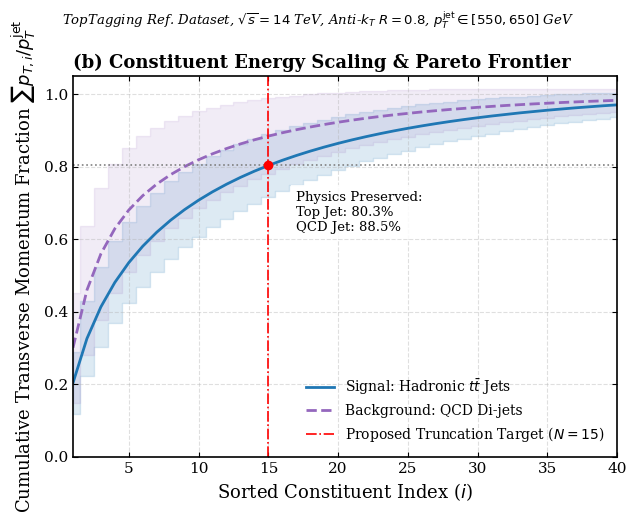

In [ ]:
# ==============================================================================
# STYLE CONFIGURATION
# ==============================================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "font.family": "serif"
})

TOP_COLOR = '#1f77b4'  # Blue for the Signal (Top Quark)
QCD_COLOR = '#9467bd'  # Purple for the Background (QCD Di-jets)

# ==============================================================================
# PARETO KINEMATIC PROCESSING (TOP TAGGING REF. DATASET)
# ==============================================================================
# Isolate the 800 columns of the 200 constituents in Cartesian format (px, py, pz, E)
X_matriz = x_qt_data[:, :800]  
y_target = y_qt_data[:, 1]    # Target variable (1: Hadronic Top, 0: QCD)

# Extract the transverse components (px, py) by skipping 4 columns at a time
p_x = X_matriz[:, 0::4]
p_y = X_matriz[:, 1::4]

# Calculate the transverse momentum (pt) of each individual particle
pt_matrix = np.sqrt(p_x**2 + p_y**2)

# Perform the cumulative sum along the particle index (column axis)
cumulative_pt = np.cumsum(pt_matrix, axis=1)

# The last cumulative element (column 200) represents the total pt of the complete Jet
total_pt = cumulative_pt[:, -1]
total_pt_safe = np.where(total_pt == 0, 1.0, total_pt) # Safe against empty jets

# Divide each step by the total pt of the jet to obtain the fraction (scale 0 to 1)
pt_fraction_matrix = cumulative_pt / total_pt_safe[:, None]

# Segregate the profile matrices according to the true class of the collider
top_profiles = pt_fraction_matrix[y_target == 1]
qcd_profiles = pt_fraction_matrix[y_target == 0]

# Calculate the mean and standard deviation for each particle index
mean_top = np.mean(top_profiles, axis=0)
std_top = np.std(top_profiles, axis=0)

mean_qcd = np.mean(qcd_profiles, axis=0)
std_qcd = np.std(qcd_profiles, axis=0)

# The X-axis denotes the actual count of integrated particles (1 to 200)
particle_indices = np.arange(1, 201)

# ==============================================================================
# CONSTRUCTION AND RENDERING OF THE DIAGRAM
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.5, 5.2))

# Signal curve (Top Quark) with 1-sigma statistical uncertainty shading
ax.plot(particle_indices, mean_top, color=TOP_COLOR, lw=2.0, label=r"Signal: Hadronic $t\bar{t}$ Jets")
ax.fill_between(particle_indices, mean_top - std_top, mean_top + std_top, 
                color=TOP_COLOR, alpha=0.15, step="mid")

# Background curve (QCD) with 1-sigma statistical uncertainty shading
ax.plot(particle_indices, mean_qcd, color=QCD_COLOR, lw=2.0, label="Background: QCD Di-jets", linestyle="--")
ax.fill_between(particle_indices, mean_qcd - std_qcd, mean_qcd + std_qcd, 
                color=QCD_COLOR, alpha=0.12, step="mid")

# --- CRITICAL INDICATORS OF THE TRUNCATION THRESHOLD ---
N_corte = 15  # Optimal point determined by the energy elbow
fraccion_en_corte_top = mean_top[N_corte - 1]

# Guide lines for geometric intersection at the cutoff point
ax.axhline(y=fraccion_en_corte_top, color='gray', linestyle=':', lw=1.2)
ax.axvline(x=N_corte, color='red', linestyle='-.', lw=1.2, 
           label=f"Proposed Truncation Target ($N={N_corte}$)")

# Visual collision node on the boundary
ax.plot(N_corte, fraccion_en_corte_top, marker='o', color='red', markersize=6)

# Explanatory text box with the exact percentage of physics preserved
texto_física = f"Physics Preserved:\nTop Jet: {fraccion_en_corte_top*100:.1f}%\nQCD Jet: {mean_qcd[N_corte-1]*100:.1f}%"
ax.text(N_corte + 2, fraccion_en_corte_top - 0.18, texto_física, 
        fontsize=9.5, bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

# --- AXIS FORMATTING STYLE ---
ax.set_xlabel("Sorted Constituent Index ($i$)")
ax.set_ylabel(r"Cumulative Transverse Momentum Fraction $\sum p_{T,i} / p_{T}^{\mathrm{jet}}$")

# Strategic zoom in the "elbow" region to appreciate the saturation of information
ax.set_xlim(1, 40)
ax.set_ylim(0.0, 1.05)

# Subplot title and detector metadata in the upper area
ax.set_title("(b) Constituent Energy Scaling & Pareto Frontier", loc="left", fontweight="bold")
fig.suptitle(r"TopTagging Ref. Dataset, $\sqrt{s} = 14$ TeV, Anti-$k_T$ $R=0.8$, $p_T^{\mathrm{jet}} \in [550, 650]$ GeV", 
             fontsize=9.5, y=0.98, style="italic")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
# fig.savefig("pareto_frontier_top_tagging.pdf", dpi=300)
plt.show()